In [ ]:
import numpy as np
import json
from pathlib import Path
from matplotlib import pyplot as plt

In [ ]:
logs_dir = Path("train_logs")

log_name = "TransformerBottleneck-model_preactivation_verynoisy_kernel_5_bce_50.json"

with open(logs_dir / log_name, 'r', encoding='utf-8') as f:
    train_log = json.load(f)["train_log"]

In [3]:
epoch = [x['epoch'] for x in train_log]
lr    = [x['lr'] for x in train_log]
train_loss = [x['train_loss'] for x in train_log]
train_dice = [x['train_dice'] for x in train_log]
test_loss = [x['test_loss'] for x in train_log]
test_dice = [x['test_dice'] for x in train_log]

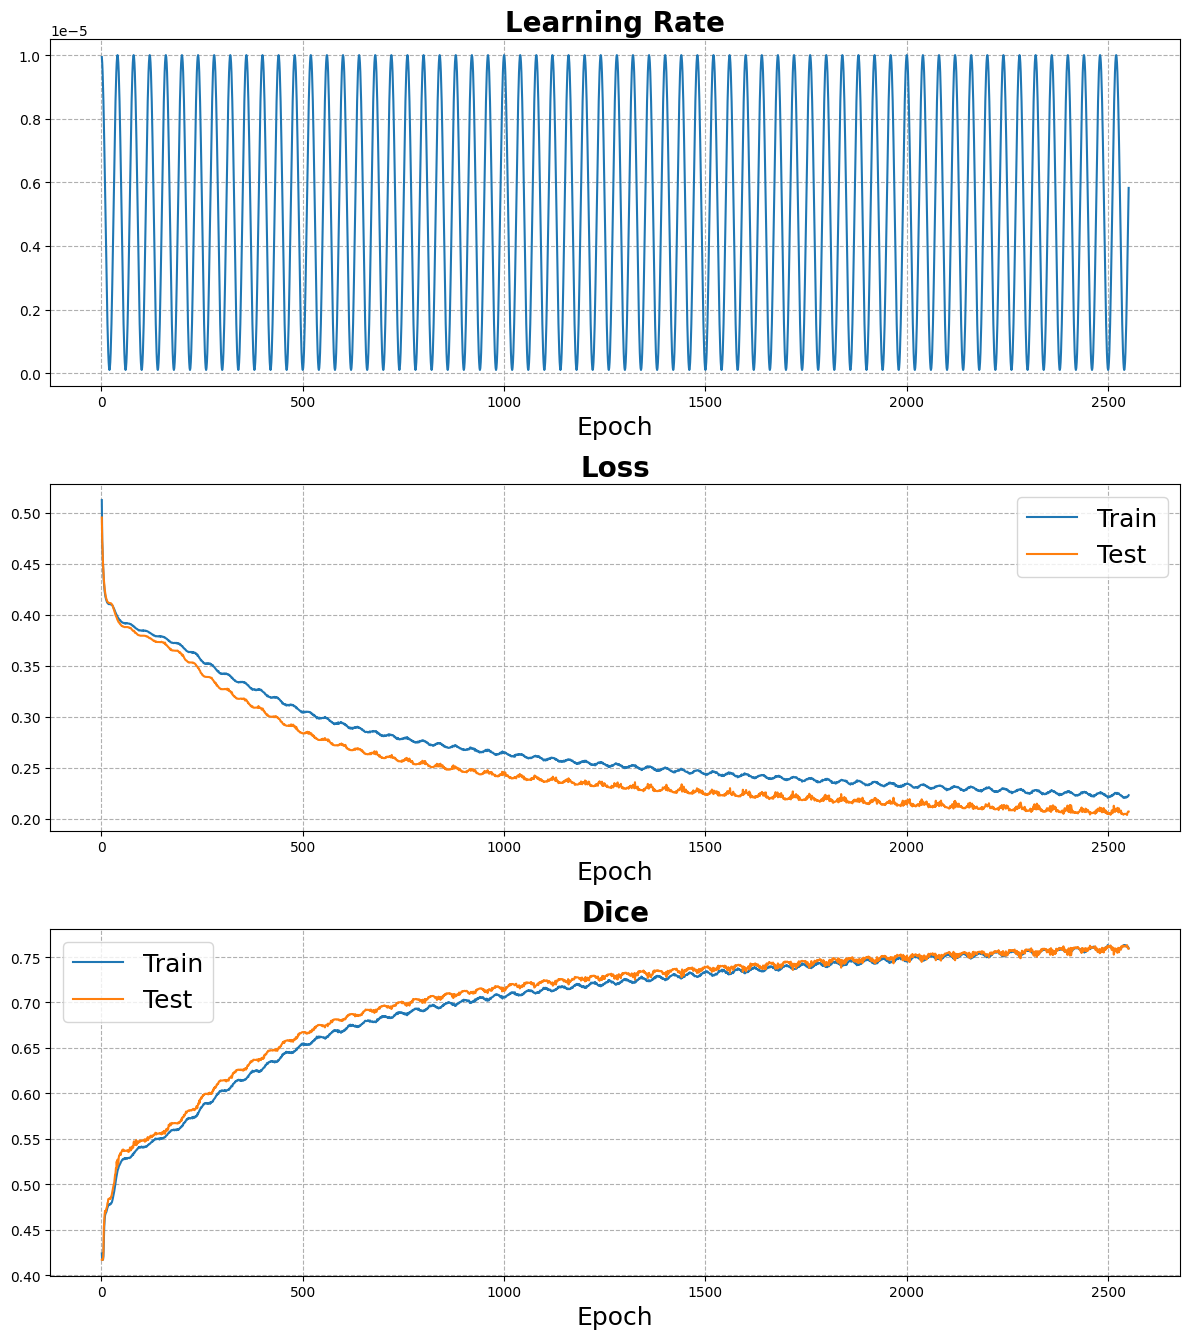

In [9]:
plot_titles = [
    'Learning Rate',
    'Loss',
    'Dice',
]
x_slice = slice(0,-1)
#x_slice = slice(500,600)
fig, axs = plt.subplots(
        nrows=len(plot_titles),
        ncols=1,
        figsize=(12, 4.5*len(plot_titles)),
        )
axs = np.array(axs).flatten()
for idx, var in enumerate([lr, [train_loss, test_loss], [train_dice, test_dice]]):
    ax = axs[idx]
    if idx == 0:
        ax.plot(epoch[x_slice], var[x_slice])
    else:
        ax.plot(epoch[x_slice], var[0][x_slice], label='Train')
        ax.plot(epoch[x_slice], var[1][x_slice], label='Test')
        ax.legend(fontsize=18)
    ax.grid(axis='both', linestyle='--')
    ax.set_xlabel('Epoch', fontsize=18)
    ax.set_title(plot_titles[idx], fontweight='bold', fontsize=20)
    
plt.tight_layout()
plt.show()